# Which of cook.py's reasons does Stockfish 18 read?

`distance_mlp.ipynb` slices one probe's predictions by **distance**. This slices them by
**reason**, and the reasons are not ours: they are the conditions inside the program that
produced the Lichess `pin` tag.

`cook.py:115` is `pin_prevents_attack(puzzle) or pin_prevents_escape(puzzle)`. Each branch
is itself a disjunction of two conditions, and cook.py collapses all four into one boolean.
`../cook_pin.py` keeps them apart — identical to the vendored source on all 6,100,960
puzzles in the export, with `any(attack.*) == prevents_attack` asserted per puzzle.

| subgroup | fires when |
|---|---|
| `attack` | either condition below |
| `attack.greater` | a pinned enemy piece attacks a solver piece **worth more than itself** and may not take it, because taking leaves the ray |
| `attack.hanging` | same, except the piece it may not take is **undefended** |
| `escape` | either condition below |
| `escape.greater` | an attacker **on the pin ray** hits a pinned piece **worth more than the attacker** |
| `escape.hanging` | the pinned piece is **hanging**, its attacker is not guarded by it, and it has moves off the ray it may not play |

`attack` and `escape` are cook.py's own names (`pin_prevents_attack`, `pin_prevents_escape`, `cook.py:577` and `:602`). The four leaf names are not: cook.py leaves the sub-conditions anonymous inside an `or`, so `.greater` and `.hanging` are named here after what they test — the value comparison and `util.is_hanging`. Neither `.hanging` is the published `hangingPiece` theme (`cook.py:242`), which is a different predicate.

| | |
|---|---|
| **Probed position** | P0 — the board the solver sees, identical to the layer sweep |
| **Layer** | `acc||tacc` only (the sweep's best), `MLPClassifier(512,128)` throughout |
| **Positives** | the `pin` tag, recomputed by `../cook_pin.py` |
| **Negatives** | not tagged `pin`, one per positive, **matched on `solver_moves`** — 50:50 |
| **Metric** | ROC AUC of a subgroup against its own matched negatives |

Two designs, the two of `distance_mlp.ipynb`:

- **Part A** — one probe, sliced by reason.
- **Part B** — a separate probe per reason.

Its equal-n sections (§9-§11, §14-§15) are not carried over. §9 below says where that costs us.

## Provenance

| File | Role |
|---|---|
| `../tools/lichess-puzzler/fetch.sh` | vendors `ornicar/lichess-puzzler` at the pinned commit |
| `../cook_pin.py` | cook.py's pin predicates and their four leaves, per position; `selftest` proves the identity |
| `auto_labels.py` | the labels, aligned to `meta.tsv` → `data/labels.npz` |

```bash
../tools/lichess-puzzler/fetch.sh
zstdcat lichess_db_puzzle.csv.zst | python ../cook_pin.py selftest   # 0 mismatches
zstdcat lichess_db_puzzle.csv.zst | python auto_labels.py
```

Folds are a plain `KFold`. Stratified folds depend on `y`, and the whole point here is that
every subgroup is scored under one partition.

## 1 · Configuration

In [1]:
from pathlib import Path
import os, sys, csv, json, time, gc, warnings

_pylibs = Path.cwd().parent / ".pylibs"
if _pylibs.is_dir() and str(_pylibs) not in sys.path:
    sys.path.insert(0, str(_pylibs))
sys.path.insert(0, str(Path.cwd()))

import numpy as np
from nnue_np import load, probe_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

HERE   = Path.cwd()
DUMP   = Path(os.environ.get("SF_PROBE_DUMP", HERE / "data" / "dump.bin"))
META   = Path(os.environ.get("SF_PROBE_META", HERE / "data" / "meta.tsv"))
LABELS = HERE / "data" / "labels.npz"
SEED = PAIR_SEED = 0
FOLDS, TEST, REPS_B = 5, 0.20, 3
LAYER = "acc||tacc"

TAG      = "" if LAYER == "acc||tacc" else "_" + LAYER.replace("||", "_")
SLUG     = LAYER.replace("||", "_")
OUT_JSON = HERE / f"results_reasons{TAG}.json"
OUT_CSV  = HERE / f"results_reasons{TAG}.csv"
PLOT     = HERE / f"reasons{TAG}.png"
CACHE    = HERE / "data" / f"oof_{SLUG}_reasons.npz"
EXP      = HERE / "data" / f"experiments_reasons{TAG}.json"

MLP = dict(hidden_layer_sizes=(512, 128), activation="relu", solver="adam", alpha=1e-4,
           batch_size=512, learning_rate_init=1e-3, max_iter=200, early_stopping=True,
           n_iter_no_change=15, validation_fraction=0.1, random_state=SEED)

BUCKETS = ["cook.attack", "cook.attack.greater", "cook.attack.hanging",
           "cook.escape", "cook.escape.greater", "cook.escape.hanging"]
TICK = {b: b.replace("cook.", "") for b in BUCKETS}
GROUPS = [("attack branch", 0, 2), ("escape branch", 3, 5)]

for p in (DUMP, META, LABELS):
    assert p.exists(), f"missing {p}"
print(f"layer {LAYER}   probe MLP{MLP['hidden_layer_sizes']}   {FOLDS}-fold, seed {SEED}")

layer acc||tacc   probe MLP(512, 128)   5-fold, seed 0


## 2 · Load

In [2]:
acts = load(str(DUMP))

rows_meta = list(csv.DictReader(open(META), delimiter="\t"))
nn     = np.array([int(x["solver_moves"]) for x in rows_meta], np.int8)
rating = np.array([int(x["rating"])       for x in rows_meta], np.int32)

z = np.load(LABELS, allow_pickle=False)
NAMES = [str(s) for s in z["names"]]
L = {nm: z["y"][:, i].astype(bool) for i, nm in enumerate(NAMES)}
y = L["cook.pin"].astype(np.int8)
assert len(acts) == len(y), f"{len(acts)} records vs {len(y)} labels — misaligned"

print(f"dataset  {len(y):,}   tagged `pin` {y.sum():,} ({y.mean()*100:.2f}%)")
print(f"the recomputed tag matches the export on "
      f"{(z['y'][:, 0] == z['export']).mean()*100:.2f}% of rows\n")
print(f"{'subgroup':22}{'fires':>9}{'of the tag':>12}")
for b in BUCKETS:
    print(f"{b:22}{L[b].sum():>9,}{L[b].sum()/y.sum()*100:>11.1f}%")

dataset  151,614   tagged `pin` 43,531 (28.71%)
the recomputed tag matches the export on 99.76% of rows

subgroup                  fires  of the tag
cook.attack              39,513       90.8%
cook.attack.greater      30,726       70.6%
cook.attack.hanging      28,194       64.8%
cook.escape               5,990       13.8%
cook.escape.greater       3,604        8.3%
cook.escape.hanging       2,426        5.6%


## 3 · Pairing

Every positive is paired with a negative of the same `solver_moves`. Without it a probe can
separate the classes on "this puzzle is long" rather than on the pin, and the subgroups
differ in length: `escape.greater` puzzles are rated 1222 on average, `escape.hanging` 1837.

In [3]:
def match_negatives(pos, rng):
    out = np.empty(len(pos), np.int64)
    for k in np.unique(nn[pos]):
        want = np.flatnonzero(nn[pos] == k)
        pool = np.flatnonzero((y == 0) & (nn == k))
        assert len(pool) >= len(want), f"length {k}: {len(want)} positives, {len(pool)} negatives"
        out[want] = rng.choice(pool, len(want), replace=False)
    return out

POS  = np.flatnonzero(y == 1)
NEG  = match_negatives(POS, np.random.default_rng(PAIR_SEED))
PAIR = np.concatenate([POS, NEG])
yp, rrp, N = y[PAIR], rating[PAIR], len(PAIR)
IN = {b: np.r_[L[b][POS], L[b][POS]] for b in BUCKETS}   # a negative inherits its partner's

assert (nn[POS] == nn[NEG]).all(), "a pair is mismatched on length"
assert len(set(NEG.tolist())) == len(NEG), "a negative was used twice"
print(f"paired set {N:,}   {yp.mean()*100:.1f}% positive")

_X = {}
def features():
    if LAYER not in _X:
        _X[LAYER] = (np.hstack([probe_matrix(acts, "acc", "both"),
                                probe_matrix(acts, "tacc", "both")])
                     if LAYER == "acc||tacc" else probe_matrix(acts, LAYER, "both")
                     if LAYER in ("acc", "tacc") else probe_matrix(acts, LAYER))
    return _X[LAYER]

def fit(rows, lab):
    Xtr = features()[rows]
    sc  = StandardScaler().fit(Xtr)
    m   = MLPClassifier(**MLP).fit(sc.transform(Xtr, copy=False), lab)
    del Xtr; gc.collect()
    return sc, m

paired set 87,062   50.0% positive


# Part A — one model, sliced by reason

One probe on the whole paired set. The subgroup decides how the held-out predictions are
sliced afterwards; the classifier never sees the reason.

## 4 · The probe

In [4]:
KEY = dict(n=N, layer=LAYER, seed=SEED, folds=FOLDS, pair_seed=PAIR_SEED,
           positives=int(yp.sum()), design="length-matched 1:1, label = cook.pin")

def train():
    splits = StratifiedKFold(FOLDS, shuffle=True, random_state=SEED).split(np.zeros(N), yp)
    oof, fold = np.full(N, np.nan), np.full(N, -1, np.int8)
    t0 = time.time()
    for i, (tr, te) in enumerate(splits):
        sc, m = fit(PAIR[tr], yp[tr])
        oof[te], fold[te] = m.predict_proba(sc.transform(features()[PAIR[te]], copy=False))[:, 1], i
        print(f"  fold {i}  epochs {m.n_iter_:>3}  AUROC {roc_auc_score(yp[te], oof[te]):.4f}"
              f"   {time.time()-t0:.0f}s", flush=True)
        del sc, m; gc.collect()
    np.savez(CACHE, oof=oof, fold=fold, key=json.dumps(KEY))
    return oof, fold

oof = fold = None
if CACHE.exists():
    zc = np.load(CACHE, allow_pickle=False)
    if json.loads(zc["key"].item()) == KEY:
        oof, fold = zc["oof"], zc["fold"]
        print(f"restored fold predictions from {CACHE.name}")
if oof is None:
    oof, fold = train()

POOLED = float(roc_auc_score(yp, oof))
fpr, tpr, thr = roc_curve(yp, oof)
THR = float(thr[np.argmax(tpr - fpr)])
print(f"pooled AUROC {POOLED:.4f}   threshold {THR:.4f}")

restored fold predictions from oof_acc_tacc_reasons.npz
pooled AUROC 0.8449   threshold 0.3430


## 5 · Sliced by reason

In [5]:
def slice_auroc(pos, neg):
    a = []
    for i in range(FOLDS):
        p, n = oof[pos & (fold == i)], oof[neg & (fold == i)]
        if len(p) < 5 or len(n) < 5:
            continue
        a.append(roc_auc_score(np.r_[np.ones(len(p)), np.zeros(len(n))], np.r_[p, n]))
    return (float(np.mean(a)), float(np.std(a)), len(a)) if a else (np.nan, np.nan, 0)

results = []
print(f"{'subgroup':22} {'n':>7} {'AUROC':>8} {'sd':>7} {'recall':>8} {'prec':>8} {'rating':>8}")
for b in BUCKETS:
    pos, neg = (yp == 1) & IN[b], (yp == 0) & IN[b]
    mu, sd, k = slice_auroc(pos, neg)
    tp = int((oof[pos] >= THR).sum()); fn = int(pos.sum()) - tp
    fp = int((oof[neg] >= THR).sum()); tn = int(neg.sum()) - fp
    results.append(dict(bucket=b, n=int(pos.sum()), n_neg=int(neg.sum()), auroc=mu, sd=sd,
                        folds=k, recall=tp/(tp+fn), precision=tp/(tp+fp) if tp+fp else float("nan"),
                        accuracy=(tp+tn)/(tp+fn+fp+tn), rating=float(rrp[pos].mean())))
    r = results[-1]
    print(f"{b:22} {r['n']:>7,} {mu:>8.4f} {sd:>7.4f} {r['recall']:>8.4f} "
          f"{r['precision']:>8.4f} {r['rating']:>8.0f}")
shared = {r["bucket"]: [r["auroc"], r["sd"]] for r in results}

subgroup                     n    AUROC      sd   recall     prec   rating
cook.attack             39,513   0.8409  0.0029   0.7851   0.7395     1658
cook.attack.greater     30,726   0.8502  0.0044   0.8006   0.7440     1647
cook.attack.hanging     28,194   0.8376  0.0039   0.7826   0.7370     1663
cook.escape              5,990   0.8911  0.0090   0.8449   0.7601     1466
cook.escape.greater      3,604   0.9660  0.0054   0.9598   0.7977     1222
cook.escape.hanging      2,426   0.7600  0.0247   0.6744   0.6903     1837


# Part B — a separate model per reason

Nothing is shared. Each subgroup gets its own probe, trained only on that subgroup's
positives against their length-matched negatives, 80-20 split, three seeds.

## 6 · One probe per reason

In [6]:
cached = json.load(open(EXP)) if EXP.exists() else {}

def per_reason(b, seed):
    rng = np.random.default_rng(1000 + seed)
    pos = np.flatnonzero((y == 1) & L[b])
    neg = match_negatives(pos, rng)
    ix  = np.concatenate([pos, neg]); lab = y[ix]
    tr, te = train_test_split(np.arange(len(ix)), test_size=TEST, random_state=seed, stratify=lab)
    sc, m = fit(ix[tr], lab[tr])
    a = float(roc_auc_score(lab[te],
              m.predict_proba(sc.transform(features()[ix[te]], copy=False))[:, 1]))
    del sc, m; gc.collect()
    return a, len(pos), len(tr)

own, own_n = {}, {}
for b in BUCKETS:
    if b in cached:
        own[b], own_n[b] = cached[b], cached[b + "_n"]
        print(f"{b:22} restored", flush=True); continue
    v = [per_reason(b, s) for s in range(REPS_B)]
    own[b]   = [float(np.mean([x[0] for x in v])), float(np.std([x[0] for x in v]))]
    own_n[b] = [v[0][1], v[0][2]]
    cached[b], cached[b + "_n"] = own[b], own_n[b]
    json.dump(cached, open(EXP, "w"), indent=1)
    print(f"{b:22} {own[b][0]:.4f} ± {own[b][1]:.4f}", flush=True)

print(f"\n{'subgroup':22}{'sliced':>9}{'own':>9}{'delta':>9}{'n_train':>10}")
for b in BUCKETS:
    print(f"{b:22}{shared[b][0]:>9.4f}{own[b][0]:>9.4f}{own[b][0]-shared[b][0]:>+9.4f}"
          f"{own_n[b][1]:>10,}")

cook.attack            restored


cook.attack.greater    restored


cook.attack.hanging    restored


cook.escape            restored


cook.escape.greater    restored


cook.escape.hanging    restored



subgroup                 sliced      own    delta   n_train
cook.attack              0.8409   0.8414  +0.0005    63,220
cook.attack.greater      0.8502   0.8681  +0.0179    49,161
cook.attack.hanging      0.8376   0.8445  +0.0069    45,110
cook.escape              0.8911   0.9615  +0.0704     9,584
cook.escape.greater      0.9660   0.9933  +0.0273     5,766
cook.escape.hanging      0.7600   0.8965  +0.1365     3,881


# Part C — one model, equal n across the four leaves

Part A trains on a set that is 91% attack-branch puzzles, so a low sliced score can mean
"the probe was mostly shown something else" rather than "the representation is weaker
there". `distance_mlp.ipynb` §9 separates those by holding n equal; this is that design.

Every leaf is cut to **2,426 positives**, the size of the smallest (`escape.hanging`), each
with its length-matched negative. One probe on the pooled strata, an 80-20 split taken
inside every stratum, then AUROC per leaf on its own held-out fifth. The two parent
branches do not take part — they contain the leaves.

## 7 · Equal n

In [7]:
LEAVES = [b for b in BUCKETS if b.count(".") == 2]
EQ_N   = min(int(((y == 1) & L[b]).sum()) for b in LEAVES)
REPS_C = 5

def _split(ix, rng):
    ix = rng.permutation(ix)
    k = int(round(len(ix) * (1 - TEST)))
    return ix[:k], ix[k:]

def equal_n(seed):
    rng = np.random.default_rng(2000 + seed)
    tr, te = [], {}
    for b in LEAVES:
        p = rng.choice(np.flatnonzero((y == 1) & L[b]), EQ_N, replace=False)
        n = match_negatives(p, rng)
        ptr, pte = _split(p, rng); ntr, nte = _split(n, rng)
        tr += [ptr, ntr]; te[b] = (pte, nte)
    rows = np.concatenate(tr)
    sc, m = fit(rows, y[rows])
    out = {}
    for b, (pte, nte) in te.items():
        pp = m.predict_proba(sc.transform(features()[pte], copy=False))[:, 1]
        pn = m.predict_proba(sc.transform(features()[nte], copy=False))[:, 1]
        out[b] = float(roc_auc_score(np.r_[np.ones(len(pp)), np.zeros(len(pn))], np.r_[pp, pn]))
    del sc, m; gc.collect()
    return out, len(rows)

KEY_C = f"eqn{EQ_N}"
if KEY_C in cached:
    eq = {k: v for k, v in cached[KEY_C].items()}
    n_train_c = cached[KEY_C + "_n"]
    print(f"restored {KEY_C} from {EXP.name}")
else:
    t0 = time.time()
    runs = [equal_n(s) for s in range(REPS_C)]
    eq = {b: [float(np.mean([r[0][b] for r in runs])),
              float(np.std([r[0][b] for r in runs]))] for b in LEAVES}
    n_train_c = runs[0][1]
    cached[KEY_C], cached[KEY_C + "_n"] = eq, n_train_c
    json.dump(cached, open(EXP, "w"), indent=1)
    print(f"{REPS_C} resamples in {(time.time()-t0)/60:.1f} min")

print("")
print(f"{EQ_N:,} positives per leaf, {n_train_c:,} training rows, "
      f"{int(EQ_N * TEST):,} held-out positives per leaf, {REPS_C} resamples")
print("")
print(f"{'leaf':22}{'A sliced':>10}{'B own':>9}{'C equal n':>11}")
for b in LEAVES:
    print(f"{b:22}{shared[b][0]:>10.4f}{own[b][0]:>9.4f}{eq[b][0]:>11.4f}")

5 resamples in 2.7 min

2,426 positives per leaf, 15,528 training rows, 485 held-out positives per leaf, 5 resamples

leaf                    A sliced    B own  C equal n
cook.attack.greater       0.8502   0.8681     0.7704
cook.attack.hanging       0.8376   0.8445     0.7777
cook.escape.greater       0.9660   0.9933     0.9770
cook.escape.hanging       0.7600   0.8965     0.8369


## 8 · Results

In [8]:
meta_out = dict(n=int(N), positive=int(yp.sum()), design="length-matched 1:1",
                pair_seed=PAIR_SEED, layer=LAYER, folds=FOLDS, seed=SEED,
                mlp={k: str(v) for k, v in MLP.items()}, pooled_auroc=POOLED, threshold=THR,
                spread_sliced=max(shared[b][0] for b in BUCKETS) - min(shared[b][0] for b in BUCKETS),
                spread_own=max(own[b][0] for b in BUCKETS) - min(own[b][0] for b in BUCKETS),
                eq_n=EQ_N, eq_reps=REPS_C, eq_train_rows=n_train_c,
                spread_eq=max(eq[b][0] for b in LEAVES) - min(eq[b][0] for b in LEAVES))
for r in results:
    r["own"], r["own_sd"] = own[r["bucket"]][0], own[r["bucket"]][1]
    r["n_train_own"] = own_n[r["bucket"]][1]
    if r["bucket"] in eq:
        r["equal_n"], r["equal_n_sd"] = eq[r["bucket"]][0], eq[r["bucket"]][1]
json.dump(dict(meta=meta_out, rows=results), open(OUT_JSON, "w"), indent=1)
with open(OUT_CSV, "w", newline="") as f:
    fn = ["bucket", "n", "n_neg", "auroc", "sd", "own", "own_sd", "n_train_own",
          "equal_n", "equal_n_sd", "folds", "recall", "precision", "accuracy", "rating"]
    w = csv.DictWriter(f, fieldnames=fn); w.writeheader()
    w.writerows({k: r.get(k) for k in fn} for r in results)
print(f"wrote {OUT_JSON.name}, {OUT_CSV.name}")

wrote results_reasons.json, results_reasons.csv


## 9 · Plot — the three designs, one above the other

In [9]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

INK, MUTED, GRID = "#0b0b0b", "#52514e", "#dedcd6"
RAMP = ["#8fbcf0", "#5598e7", "#3987e5", "#256abf", "#184f95", "#0d366b"]
HALO = [pe.withStroke(linewidth=3.4, foreground="white")]

def panel(ax, res, headline, ticks, top):
    have = [i for i, b in enumerate(BUCKETS) if b in res]
    x    = np.array(have)
    vals = np.array([res[BUCKETS[i]][0] for i in have])
    sds  = np.array([res[BUCKETS[i]][1] for i in have])
    ramp = [RAMP[int(round(k * (len(RAMP) - 1) / max(len(have) - 1, 1)))] for k in range(len(have))]
    colors = [ramp[i] for i in vals.argsort().argsort()]
    hi = top - (top - 0.5) * 0.06          # headroom for the group labels, shared scale

    for gi, (lab, a, b) in enumerate(GROUPS):
        if gi % 2 == 1:
            ax.axvspan(a - 0.5, b + 0.5, color="#f4f3ef", zorder=0)
        if a:
            ax.vlines(a - 0.5, 0.5, hi, color="#c9c8c2", lw=1.1, zorder=2)
        ax.text((a + b) / 2, hi + (top - 0.5) * 0.02, lab, fontsize=9.2,
                color=MUTED, ha="center", style="italic", zorder=7, path_effects=HALO)

    ax.bar(x, vals - 0.5, bottom=0.5, width=0.66, color=colors, zorder=3)
    ax.errorbar(x, vals, yerr=sds, fmt="none", ecolor="#ffffff", elinewidth=1.6, capsize=0, zorder=4)
    ax.errorbar(x, vals, yerr=sds, fmt="none", ecolor=INK, elinewidth=0.9, capsize=3,
                alpha=.55, zorder=5)
    peak = have[int(vals.argmax())]
    for i, v in zip(have, vals):
        ax.text(i, v + sds[list(have).index(i)] + 0.004, f"{v:.3f}", ha="center", fontsize=9.3, color=INK,
                weight="bold" if i == peak else "normal", zorder=7, path_effects=HALO)

    ax.set_ylim(0.5, top); ax.set_xlim(-0.5, len(BUCKETS) - 0.4)
    ax.set_xticks(np.arange(len(BUCKETS)))
    ax.set_xticklabels([TICK[b] for b in BUCKETS] if ticks else [], fontsize=9.6, color=INK)
    ax.set_ylabel(headline, fontsize=10.2, color=INK, labelpad=9)
    ax.tick_params(axis="y", labelsize=9.5, colors=MUTED, length=0)
    ax.tick_params(axis="x", length=0)
    ax.grid(axis="y", color=GRID, lw=0.7, zorder=1); ax.set_axisbelow(True)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.spines["bottom"].set_color(GRID)

# one scale for both panels, or the same number would draw at two heights
TOP = 0.5 + (max(max(v[0] + v[1] for v in shared.values()),
                 max(v[0] + v[1] for v in own.values()),
                 max(v[0] + v[1] for v in eq.values())) - 0.5) * 1.15
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(11.2, 13.2), sharex=True)
fig.patch.set_facecolor("white")
panel(ax1, shared, "A · one model, sliced\nAUROC", False, TOP)
panel(ax2, own,    "B · a model per reason\nAUROC", False, TOP)
panel(ax3, eq,     f"C · one model, {EQ_N:,} per leaf\nAUROC", True, TOP)
for a in (ax1, ax2, ax3):
    a.set_facecolor("white")

ax3.set_xlabel("the reason the pin is doing work  (subgroups overlap and have no order)",
               fontsize=10.5, color=INK, labelpad=52)
for k, r in enumerate(results):
    ax3.annotate(f"{r['n']:,} pairs\nrated {r['rating']:.0f}", xy=(k, 0),
                 xycoords=("data", "axes fraction"), textcoords="offset points",
                 xytext=(0, -30), fontsize=8.0, color=MUTED, ha="center", va="top",
                 annotation_clip=False)

ax1.text(0, 1.30, "Which of cook.py's reasons does Stockfish 18 read?",
         transform=ax1.transAxes, fontsize=14, color=INK, va="bottom", weight="bold")
ax1.text(0, 1.045,
         f"MLP probe on {LAYER} · {N:,} rows, 50:50, negatives matched on puzzle length\n"
         f"cook.py's `pin` tag is `attack or escape`, each branch a disjunction of two "
         f"conditions, split out here\n"
         f"A: one probe, {FOLDS}-fold, sliced afterwards · B: one probe per subgroup, 80-20 "
         f"split, mean of {REPS_B} seeds · darker = higher · both axes start at chance (0.500)",
         transform=ax1.transAxes, fontsize=9.5, color=MUTED, va="bottom", linespacing=1.5)

fig.subplots_adjust(hspace=0.16)
fig.savefig(PLOT, dpi=170, bbox_inches="tight", facecolor="white")
print(f"wrote {PLOT.name}")
plt.close(fig)

wrote reasons.png


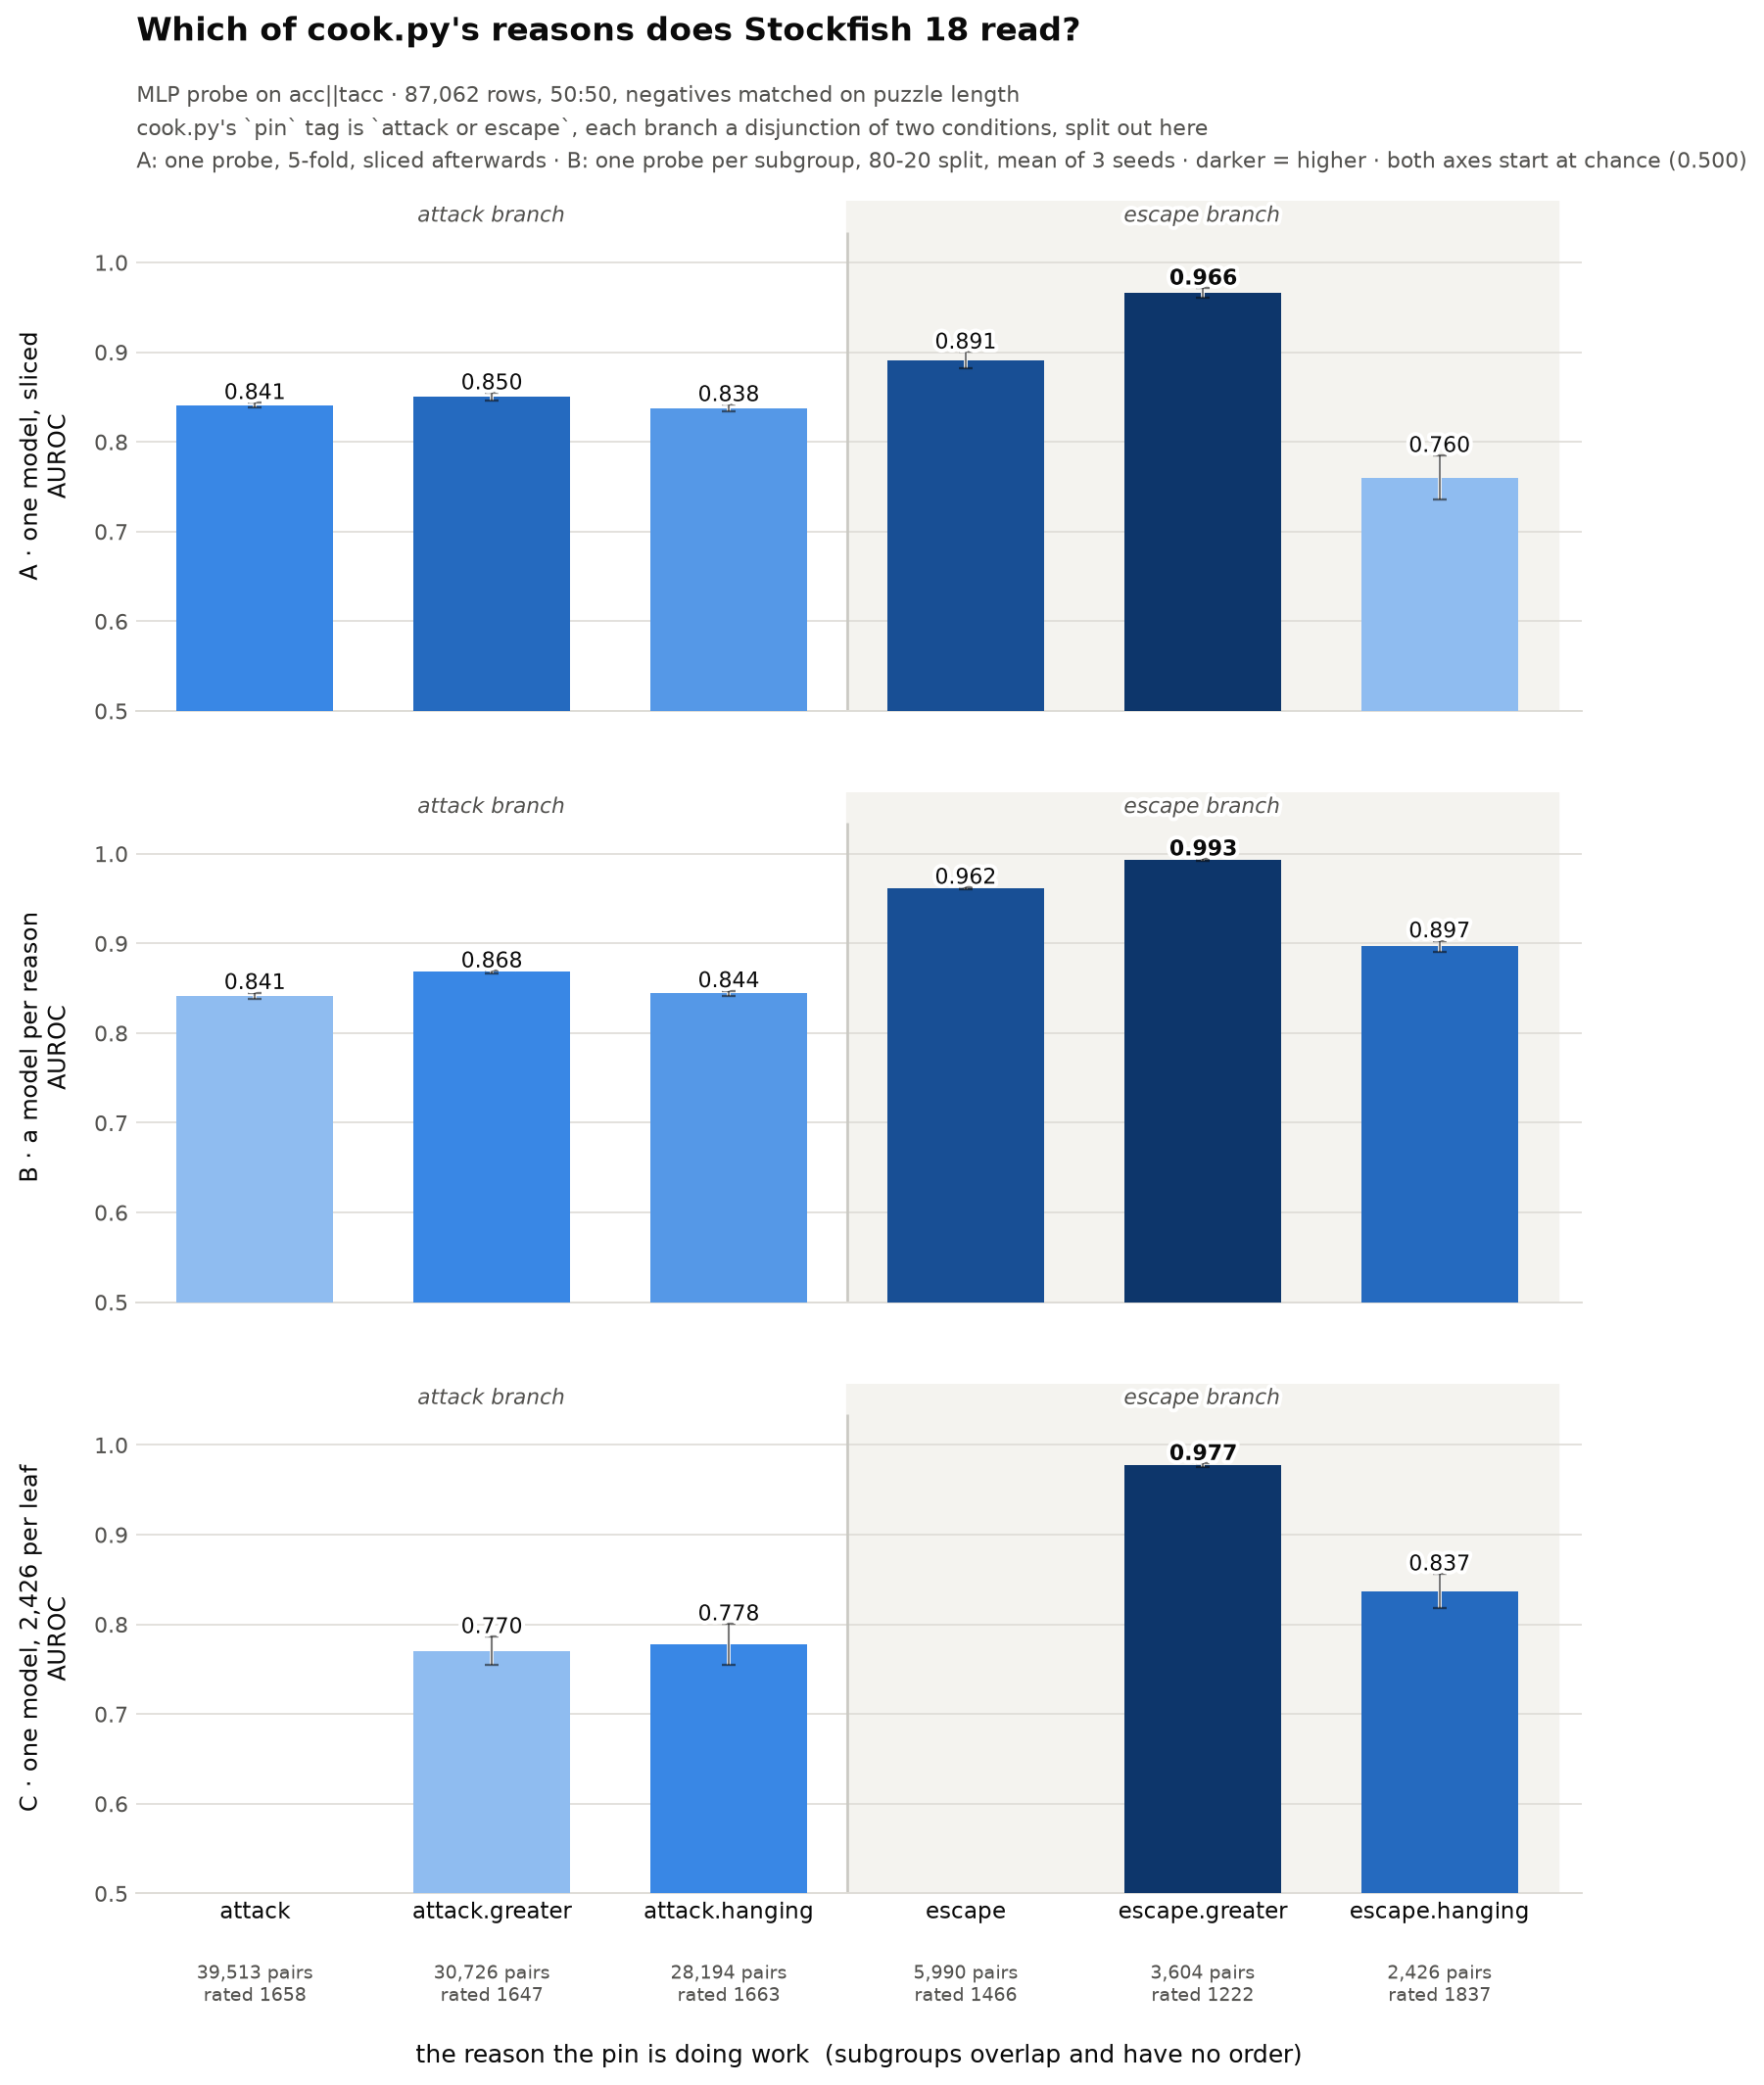

In [10]:
from IPython.display import Image, display
display(Image(filename=str(PLOT)))

## 10 · Reading it

**The tag hides a 0.21 gap inside one of its own branches.** Sliced, `escape.greater` reads
at 0.966 and `escape.hanging` at 0.760; cook.py `or`s them into one boolean and the branch
reports 0.891. The attack branch splits by 0.012 and hides nothing.

**The easy half is the one where material is already hanging.** `escape.greater` — the
pinned piece is worth more than the attacker on its ray — is the lowest-rated subgroup in
the set (1222) and the most readable. A probe trained on it alone reaches 0.993. That is
close to reading material rather than reading pins, and it is the number to be most
sceptical of.

**Part B moves `escape.hanging` the most.** 0.760 sliced against 0.897 with its own probe,
+0.137, where the attack branch gains +0.001. The shared probe is fit on a set that is 91%
attack-branch puzzles, so the sliced figure measures training share as much as it measures
the representation. `escape.hanging` is not hard for the network to carry; it is hard for a
probe that was mostly shown something else.

**What separates those two readings is the control we dropped.** `distance_mlp.ipynb` §9-§11
holds n equal across buckets precisely to tell "the probe specialised" from "the
representation degrades". Bringing it back for the two escape leaves is what would settle
the paragraph above rather than argue it.

Caveats unchanged from the sweep: the label is one program's rule, not ground truth, and it
is a property of positions one ply past the one the probe sees.